# 05 - Unsupervised Learning

# Segmentación de empleados mediante aprendizaje no supervisado

En este notebook se aplican técnicas de aprendizaje no supervisado para descubrir patrones naturales dentro de la población de empleados.

A diferencia del aprendizaje supervisado, aquí no se busca predecir una variable objetivo específica.

El propósito principal es:

- identificar grupos naturales de empleados;
- descubrir patrones ocultos en comportamiento de desempeño;
- segmentar empleados por perfiles de RRHH;
- detectar perfiles similares en ausencias, capacitaciones y competencias;
- analizar estructuras internas del dataset.

Las técnicas utilizadas serán:

- PCA (Principal Component Analysis);
- KMeans Clustering;
- Método del codo;
- Silhouette Score;
- Visualización de clusters.

La pregunta principal es:

> ¿Qué grupos naturales existen dentro de la población de empleados?


# Objetivos del notebook

En esta etapa del proyecto se busca:

- reducir dimensionalidad mediante PCA;
- visualizar relaciones complejas entre empleados;
- encontrar clusters naturales de perfiles de RRHH;
- interpretar grupos organizacionales;
- detectar empleados de alto y bajo desempeño;
- analizar perfiles de ausencias y capacitaciones por segmento.

Este análisis complementa el enfoque supervisado realizado anteriormente.


# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

# Ruta raíz del proyecto.
project_root = r'C:\Users\Arturo\Desktop\Prueba1'


# 2. Carga del dataset

In [2]:
df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print("Dimensiones del dataset:")
print(df.shape)

df.head()


Dimensiones del dataset:
(478, 35)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,0.693147,2.833213,0.693147,2.041220
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148.0,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,NaN,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,11.4,0.020500,0.75,1,0,1,0,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80.0,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,6.5,0.017500,0.00,0,0,0,0,1.098612,0.693147,4.394449,0.000000,2.014903


# 3. Variables para clustering

Se seleccionan variables numéricas representativas del perfil de RRHH de cada empleado.

Se excluyen variables categóricas (departamento, cargo, contrato, jornada) ya que KMeans y PCA requieren entrada numérica.

También se excluye `puntaje_desempeno` del clustering para usarla después como variable de validación externa de los clusters.


In [3]:
variables_cluster = [
    # Ausencias.
    "total_dias_ausencia",
    "promedio_dias_ausencia",
    "max_dias_ausencia",
    "ausencia_alta",
    # Capacitaciones.
    "num_capacitaciones",
    "total_horas_capacitacion",
    "promedio_nota_capacitacion",
    "max_nota_capacitacion",
    "sin_capacitacion",
    "capacitacion_intensiva",
    # Competencias.
    "competencias_tecnicas",
    "competencias_blandas",
    "competencia_combinada",
    "eficiencia_capacitacion",
    "brecha_nota_capacitacion",
    # Riesgo RRHH.
    "riesgo_operacional_rrhh",
    # Versiones logarítmicas.
    "total_dias_ausencia_log",
    "num_capacitaciones_log",
    "total_horas_capacitacion_log",
    "competencia_combinada_log"
]

variables_cluster = [v for v in variables_cluster if v in df.columns]

print("Cantidad de variables:")
print(len(variables_cluster))

variables_cluster


Cantidad de variables:
20


['total_dias_ausencia',
 'promedio_dias_ausencia',
 'max_dias_ausencia',
 'ausencia_alta',
 'num_capacitaciones',
 'total_horas_capacitacion',
 'promedio_nota_capacitacion',
 'max_nota_capacitacion',
 'sin_capacitacion',
 'capacitacion_intensiva',
 'competencias_tecnicas',
 'competencias_blandas',
 'competencia_combinada',
 'eficiencia_capacitacion',
 'brecha_nota_capacitacion',
 'riesgo_operacional_rrhh',
 'total_dias_ausencia_log',
 'num_capacitaciones_log',
 'total_horas_capacitacion_log',
 'competencia_combinada_log']

# 4. Preparación de datos

Antes de aplicar clustering:

- se imputan valores faltantes con la mediana;
- se escalan las variables con StandardScaler;
- se prepara una matriz numérica limpia para PCA y KMeans.

El escalamiento es fundamental porque KMeans es sensible a magnitudes distintas entre variables.


In [4]:
X = df[variables_cluster].copy()

pipeline_preprocesamiento = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

X_preparado = pipeline_preprocesamiento.fit_transform(X)

print("Shape final:")
print(X_preparado.shape)


Shape final:
(478, 20)


# 5. Reducción de dimensionalidad con PCA

PCA permite reducir la dimensionalidad del espacio de variables a 2 componentes principales.

Esto facilita:

- visualización bidimensional de los empleados;
- interpretación de relaciones entre perfiles;
- clustering en un espacio reducido;
- detección de patrones y agrupaciones.

En este caso se reducirá a 2 componentes para visualización directa.


In [5]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_preparado)

print("Shape PCA:")
print(X_pca.shape)

print("\nVarianza explicada por componente:")
print(pca.explained_variance_ratio_.round(4))

print("\nVarianza acumulada (2 componentes):")
print(round(np.sum(pca.explained_variance_ratio_), 4))


Shape PCA:
(478, 2)

Varianza explicada por componente:
[0.3325 0.2246]

Varianza acumulada (2 componentes):
0.5571


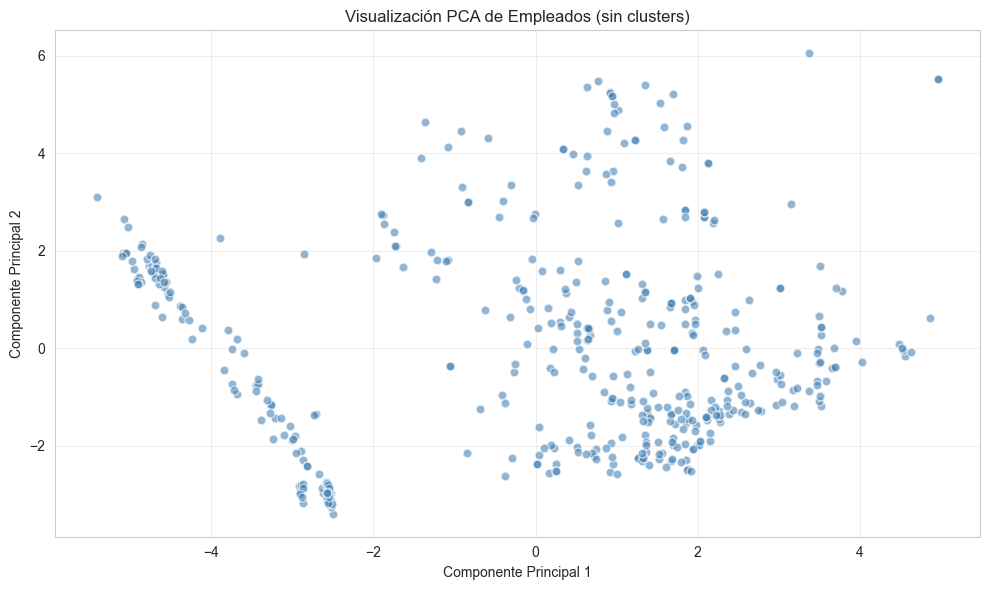

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            alpha=0.6, color="steelblue", edgecolors="white", s=40)
plt.title("Visualización PCA de Empleados (sin clusters)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/05_pca_sin_clusters.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Análisis PCA

El PCA permite observar si existen agrupaciones naturales dentro de la población de empleados.

Si aparecen zonas densas o grupos separados, esto puede indicar la existencia de perfiles de RRHH diferenciados en términos de ausencias, capacitaciones y competencias.


# 6. Método del codo

Antes de aplicar KMeans, se utilizará el método del codo para estimar una cantidad adecuada de clusters.

Se evaluarán valores de K entre 2 y 10.


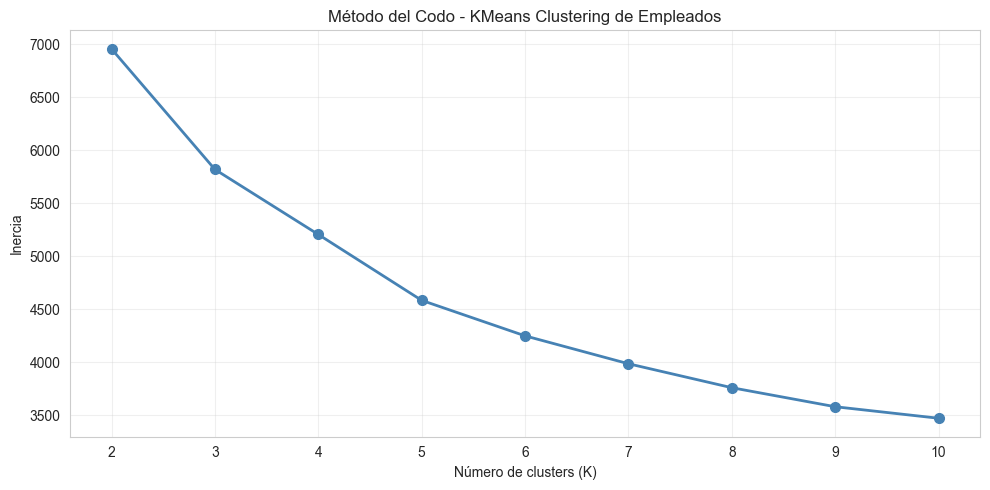

In [7]:
inercias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_preparado)
    inercias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inercias, marker="o", color="steelblue",
         linewidth=2, markersize=7)
plt.title("Método del Codo - KMeans Clustering de Empleados")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/05_metodo_codo.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Análisis del método del codo

El objetivo es encontrar un punto donde la reducción de inercia comienza a estabilizarse.

Ese punto representa un equilibrio entre:

- simplicidad del modelo;
- separación de los clusters;
- capacidad explicativa de los perfiles encontrados.


# 7. Evaluación con Silhouette Score

Además del método del codo, se calculará el silhouette score para distintos valores de K.

Esta métrica mide qué tan separados y compactos están los clusters.

Un silhouette score más cercano a 1 indica clusters bien definidos y diferenciados.


K=2  →  Silhouette: 0.2761
K=3  →  Silhouette: 0.2581
K=4  →  Silhouette: 0.2150
K=5  →  Silhouette: 0.2261
K=6  →  Silhouette: 0.2178
K=7  →  Silhouette: 0.2171
K=8  →  Silhouette: 0.2182
K=9  →  Silhouette: 0.2186
K=10  →  Silhouette: 0.2126


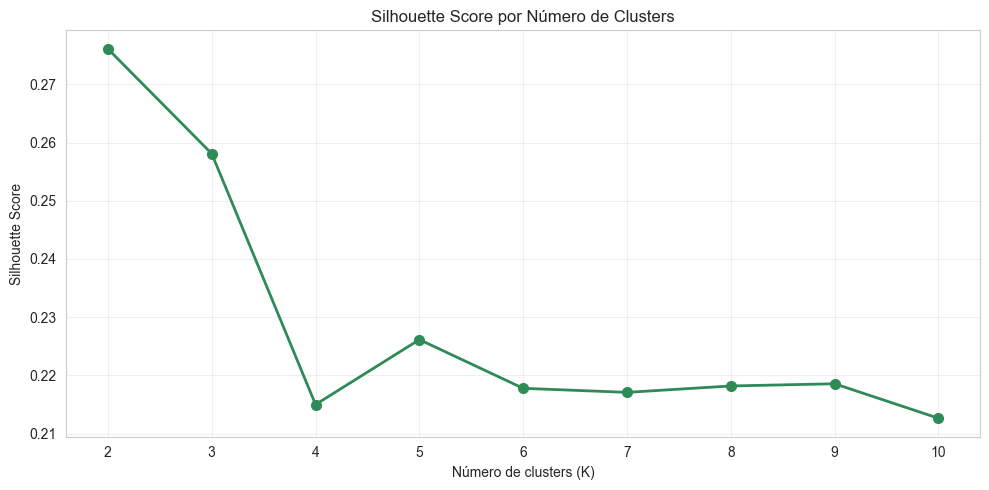


K óptimo según Silhouette Score: 2


In [8]:
silhouettes = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_preparado)
    score  = silhouette_score(X_preparado, labels)
    silhouettes.append(score)
    print(f"K={k}  →  Silhouette: {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouettes, marker="o", color="seagreen",
         linewidth=2, markersize=7)
plt.title("Silhouette Score por Número de Clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/05_silhouette_score.png'),
            dpi=150, bbox_inches='tight')
plt.show()

k_optimo = list(k_range)[int(np.argmax(silhouettes))]
print(f"\nK óptimo según Silhouette Score: {k_optimo}")


## Análisis del Silhouette Score

El silhouette score complementa el método del codo al cuantificar la calidad de los clusters.

Se elegirá el K que combine un codo visible en la inercia con un silhouette score alto.

Esto garantiza que los grupos encontrados sean:

- coherentes internamente (empleados similares entre sí dentro de cada cluster);
- diferenciados entre clusters (perfiles claramente distintos entre grupos).


# 8. Aplicación de KMeans con el K óptimo

Se entrena KMeans con el número de clusters seleccionado y se asigna un cluster a cada empleado.


In [9]:
# Si prefieres fijar un K manualmente, reemplaza k_optimo con el valor deseado.
# k_optimo = 4

kmeans_final   = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df["cluster"]  = kmeans_final.fit_predict(X_preparado)

print("Distribución de empleados por cluster:")
print(df["cluster"].value_counts().sort_index())

print("\nProporción por cluster:")
print((df["cluster"].value_counts(normalize=True)
       .sort_index() * 100).round(1))


Distribución de empleados por cluster:
cluster
0    337
1    141
Name: count, dtype: int64

Proporción por cluster:
cluster
0    70.5
1    29.5
Name: proportion, dtype: float64


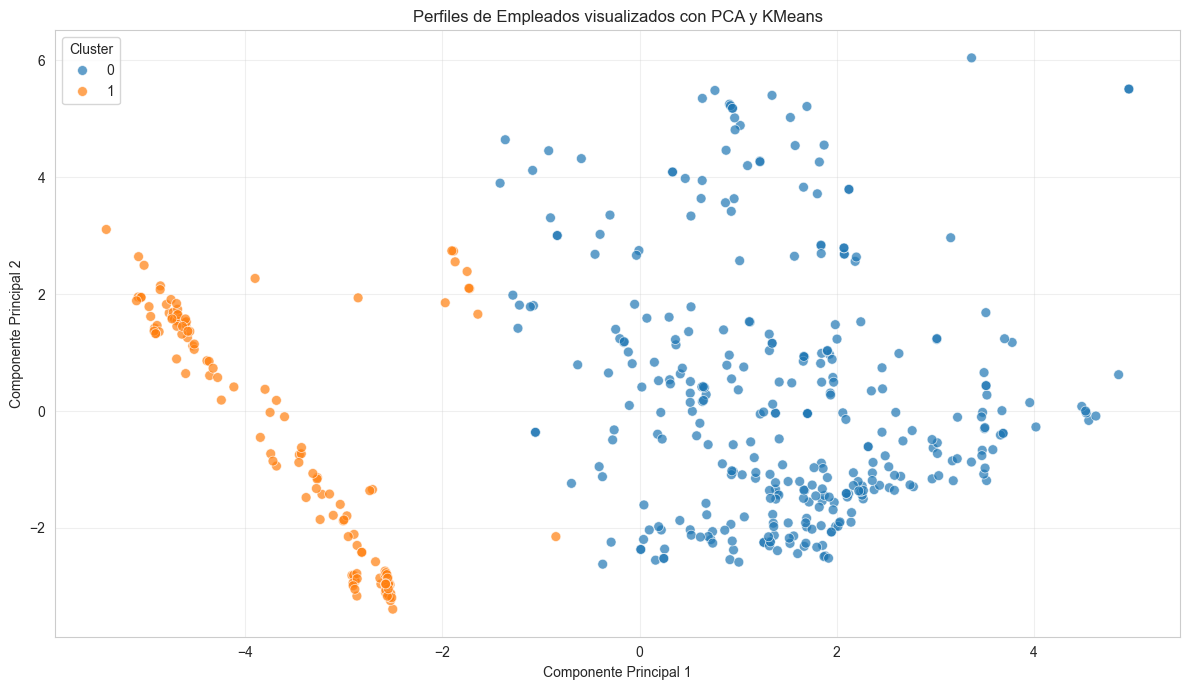

In [10]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["cluster"],
    palette="tab10",
    alpha=0.7,
    s=50
)
plt.title("Perfiles de Empleados visualizados con PCA y KMeans")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/05_pca_con_clusters.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Análisis visual de clusters

La visualización permite observar:

- qué tan separados están los grupos de empleados en el espacio PCA;
- si existen clusters dominantes en tamaño;
- si hay empleados extremos o atípicos;
- si aparecen perfiles de RRHH claramente diferenciados.

Esto ayuda a interpretar la estructura de la población de empleados.


# 9. Caracterización de clusters

Se analizarán las características promedio de cada cluster para comprender qué tipo de empleados los componen.


In [11]:
variables_analisis = [
    "puntaje_desempeno",
    "competencias_tecnicas",
    "competencias_blandas",
    "total_dias_ausencia",
    "num_capacitaciones",
    "promedio_nota_capacitacion",
    "riesgo_operacional_rrhh",
    "ausencia_alta",
    "sin_capacitacion"
]

variables_analisis = [v for v in variables_analisis if v in df.columns]

perfil_clusters = df.groupby("cluster")[variables_analisis].mean().round(3)

perfil_clusters


,puntaje_desempeno,competencias_tecnicas,competencias_blandas,total_dias_ausencia,num_capacitaciones,promedio_nota_capacitacion,riesgo_operacional_rrhh,ausencia_alta,sin_capacitacion
cluster,,,,,,,,,
0,4.538,4.255,4.012,11.591,1.703,4.073,0.436,0.169,0.003
1,4.735,4.142,4.160,19.518,0.043,0.219,1.660,0.454,0.957


# 10. Puntaje de desempeño por cluster

Se analiza cómo varía el puntaje de desempeño entre los distintos clusters de empleados.

Esta es la variable objetivo del proyecto supervisado, usada aquí como validación externa del clustering.


C:\Users\Arturo\AppData\Local\Temp\ipykernel_14848\4016363239.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


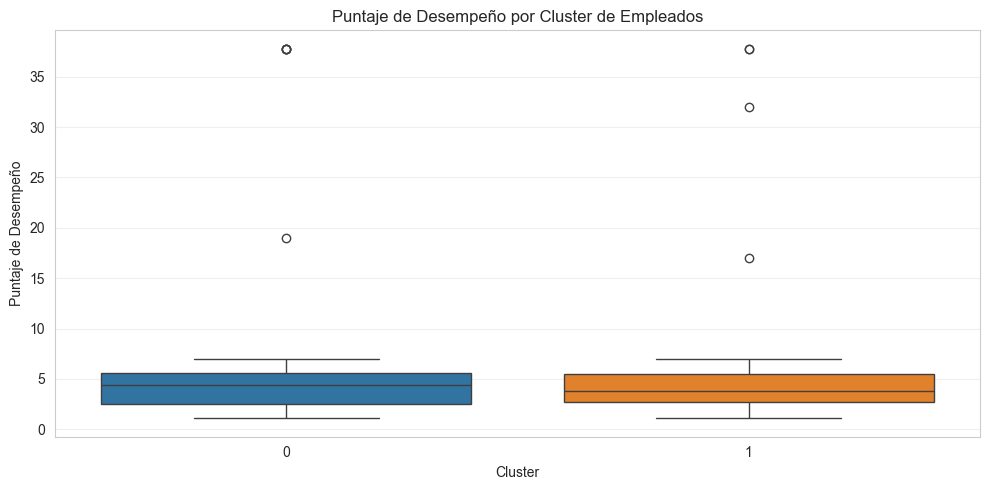

In [12]:
if "puntaje_desempeno" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df,
        x="cluster",
        y="puntaje_desempeno",
        palette="tab10"
    )
    plt.title("Puntaje de Desempeño por Cluster de Empleados")
    plt.xlabel("Cluster")
    plt.ylabel("Puntaje de Desempeño")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/05_desempeno_por_cluster.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


# 11. Ausencias por cluster

Se analiza el comportamiento de las ausencias dentro de cada cluster para identificar grupos con alta o baja inasistencia.


C:\Users\Arturo\AppData\Local\Temp\ipykernel_14848\3211158224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


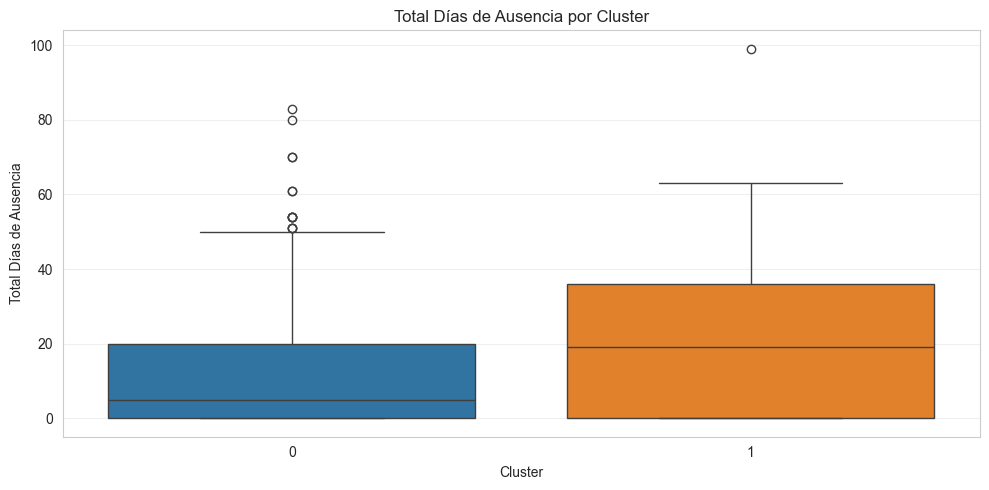

In [13]:
if "total_dias_ausencia" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df,
        x="cluster",
        y="total_dias_ausencia",
        palette="tab10"
    )
    plt.title("Total Días de Ausencia por Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Total Días de Ausencia")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/05_ausencias_por_cluster.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


# 12. Competencias y capacitaciones por cluster

Se analiza el nivel de competencias técnicas y el desempeño en capacitaciones para cada cluster.


C:\Users\Arturo\AppData\Local\Temp\ipykernel_14848\2322234226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Arturo\AppData\Local\Temp\ipykernel_14848\2322234226.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


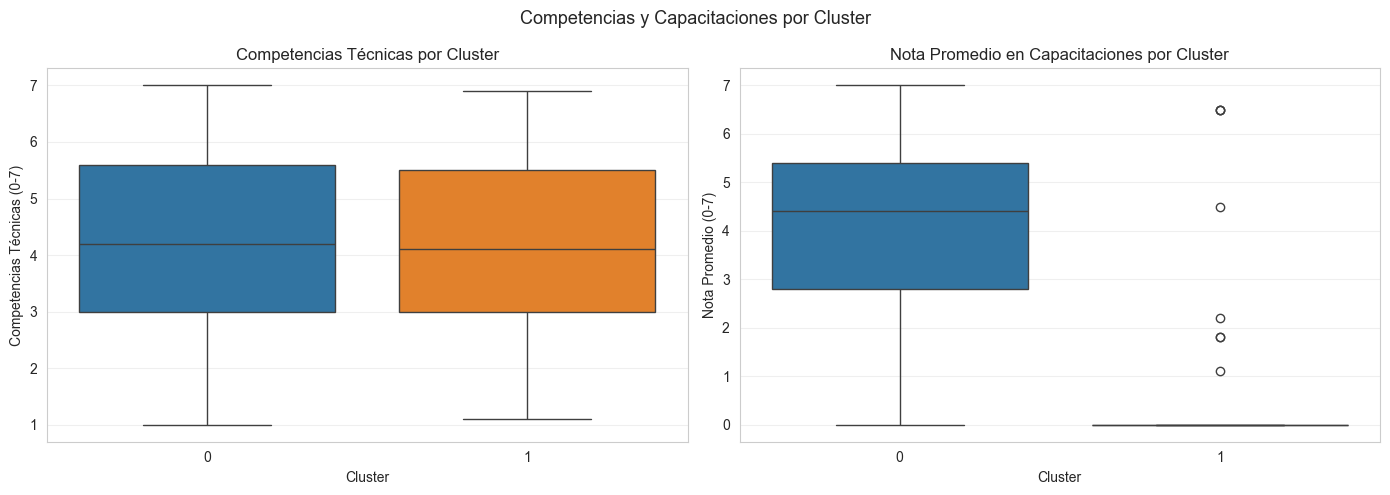

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "competencias_tecnicas" in df.columns:
    sns.boxplot(
        data=df, x="cluster", y="competencias_tecnicas",
        palette="tab10", ax=axes[0]
    )
    axes[0].set_title("Competencias Técnicas por Cluster")
    axes[0].set_xlabel("Cluster")
    axes[0].set_ylabel("Competencias Técnicas (0-7)")
    axes[0].grid(alpha=0.3, axis="y")

if "promedio_nota_capacitacion" in df.columns:
    sns.boxplot(
        data=df, x="cluster", y="promedio_nota_capacitacion",
        palette="tab10", ax=axes[1]
    )
    axes[1].set_title("Nota Promedio en Capacitaciones por Cluster")
    axes[1].set_xlabel("Cluster")
    axes[1].set_ylabel("Nota Promedio (0-7)")
    axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("Competencias y Capacitaciones por Cluster", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/05_competencias_capacitaciones_cluster.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# 13. Resumen de clusters encontrados

In [15]:
vars_resumen_base = {
    "puntaje_desempeno":          ["mean", "max"],
    "total_dias_ausencia":        "mean",
    "num_capacitaciones":         "mean",
    "promedio_nota_capacitacion": "mean"
}

vars_resumen_filtradas = {k: v for k, v in vars_resumen_base.items() if k in df.columns}

resumen_clusters = df.groupby("cluster").agg(vars_resumen_filtradas).round(3)

resumen_clusters


puntaje_desempeno        total_dias_ausencia num_capacitaciones  \
                     mean    max                mean               mean   
cluster                                                                   
0                   4.538  37.76              11.591              1.703   
1                   4.735  37.76              19.518              0.043   

        promedio_nota_capacitacion  
                              mean  
cluster                             
0                            4.073  
1                            0.219

In [16]:
# Tamaño de cada cluster.
tamanio = df["cluster"].value_counts().sort_index().rename("n_empleados")
print("Empleados por cluster:")
print(tamanio.to_frame())


Empleados por cluster:
         n_empleados
cluster             
0                337
1                141


# 14. Conclusiones del notebook

En este notebook se aplicaron técnicas de aprendizaje no supervisado para segmentar la población de empleados de la organización.

Se utilizaron:

- PCA para reducción de dimensionalidad y visualización;
- KMeans para identificar grupos naturales;
- método del codo para estimar el K adecuado;
- silhouette score para validar la calidad de los clusters.

El análisis permitió identificar grupos naturales dentro de la organización. Los clusters encontrados pueden representar perfiles como:

- empleados de alto desempeño con muchas capacitaciones y pocas ausencias;
- empleados con ausencias frecuentes y bajo rendimiento;
- empleados sin capacitaciones pero con buen nivel de competencias;
- empleados con perfiles mixtos o en proceso de desarrollo.

Además, PCA permitió visualizar la estructura interna del dataset y detectar si los grupos tienen separación real en el espacio de variables de RRHH.

Este análisis complementa el modelado supervisado realizado anteriormente, agregando una perspectiva exploratoria y estratégica sobre la gestión de personas.
